In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.animation as animation
from geopy.geocoders import Nominatim
from time import sleep

In [2]:
# Skip the data-processing
processed_ds = xr.open_dataset("/data/keeling/a/alison8/AlisonCapstone/wrf_framinputs_14dec2024.nc")
processed_ds

<xarray.Dataset> Size: 159MB
Dimensions:      (time: 97, south_north: 319, west_east: 319)
Coordinates:
  * time         (time) datetime64[ns] 776B 2024-12-14 ... 2024-12-16
    XLAT         (south_north, west_east) float32 407kB ...
    XLONG        (south_north, west_east) float32 407kB ...
Dimensions without coordinates: south_north, west_east
Data variables:
    precip_rate  (time, south_north, west_east) float32 39MB ...
    wind_speed   (time, south_north, west_east) float32 39MB ...
    wetbulb      (time, south_north, west_east) float64 79MB ...
Attributes:
    description:      WRF-derived FRAM input variables
    time_resolution:  30 minutes
    units:            precip_rate=mm/hr, wind_speed=m/s, wetbulb=degC

In [3]:
# Source
# Sanders & Barjenbruch (2016)
# “Analysis of Ice-to-Liquid Ratios during Freezing Rain and the Development of an Ice Accumulation Model”
# FRAM Ice Accretion Calculation

# Convert wind speed to knots (FRAM requires knots)
wind_kt = processed_ds.wind_speed * 1.94384

# Regime masks: regression equations were derived separately for three precipitation-rate categories
mask1 = processed_ds.precip_rate < 0.5
mask2 = (processed_ds.precip_rate >= 0.5) & (processed_ds.precip_rate < 2.5)
mask3 = processed_ds.precip_rate >= 2.5

# Initialize ILR
ilr = xr.zeros_like(processed_ds.precip_rate)

# Apply FRAM equations (implemented in vectorized xarray form, though algebraically identical to paper)
ilr = xr.where(mask1, 0.73 - 0.29 * processed_ds.precip_rate - 0.01 * processed_ds.wetbulb + 0.01 * wind_kt, ilr)
ilr = xr.where(mask2, 0.81 - 0.18 * processed_ds.precip_rate - 0.01 * processed_ds.wetbulb + 0.01 * wind_kt, ilr)
ilr = xr.where(mask3, 0.93 - 0.06 * processed_ds.precip_rate - 0.01 * processed_ds.wetbulb + 0.01 * wind_kt, ilr)

# Physical constraints: ILR is bounded between 0 and 1
ilr = ilr.clip(min=0.0, max=1.0)

# The paper applies FRAM only under freezing rain conditions
ilr = xr.where(processed_ds.wetbulb <= 0.0, ilr, 0.0)

# Add ILR to dataset
processed_ds["ILR"] = ilr

# Ice Accretion Rate (mm/hr)
# follows from paper-defined ice accretion
processed_ds["ice_rate"] = processed_ds.ILR * processed_ds.precip_rate

# Time-integrated Ice Thickness
dt = 0.5  # 30-min timestep

processed_ds["ice_thickness"] = (processed_ds.ice_rate * dt).cumsum(dim="time")

In [4]:
# extra stuff for analysis suite below

def setup_map(ax):
    ax.add_feature(cfeature.STATES, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=1)
    counties = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_2_counties',
        scale='10m',
        facecolor='none'
    )
    ax.add_feature(counties, edgecolor='gray', linewidth=0.3)

lats = processed_ds.XLAT
lons = processed_ds.XLONG

# Conversion factor
MM_TO_IN = 0.0393701

processed_ds["ice_thickness_in"] = processed_ds.ice_thickness * MM_TO_IN
processed_ds["ice_rate_in"] = processed_ds.ice_rate * MM_TO_IN

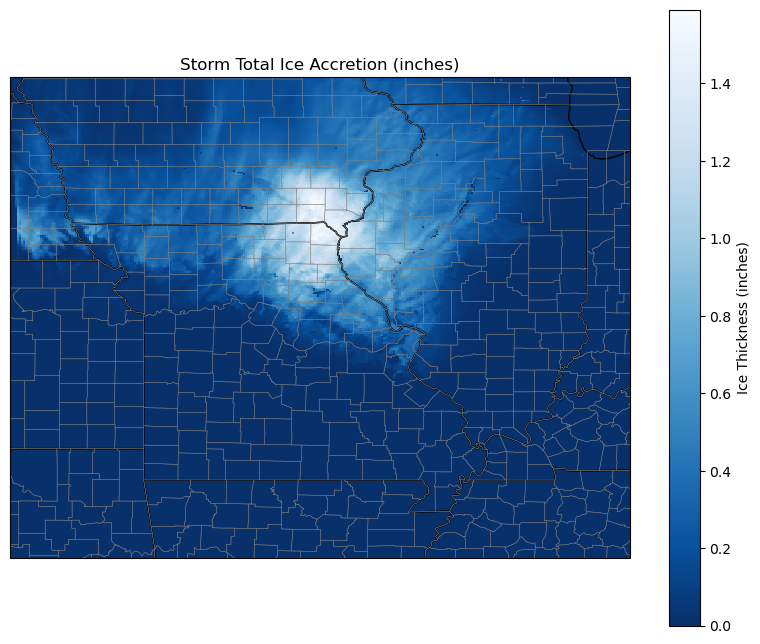

In [5]:
# total ice accretion from the storm
storm_total = processed_ds.ice_thickness_in.isel(time=-1)

plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = ax.pcolormesh(lons, lats, storm_total, transform=ccrs.PlateCarree(), cmap="Blues_r")
setup_map(ax)
ax.set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())
plt.colorbar(mesh, label="Ice Thickness (inches)")
plt.title("Storm Total Ice Accretion (inches)")
plt.show()

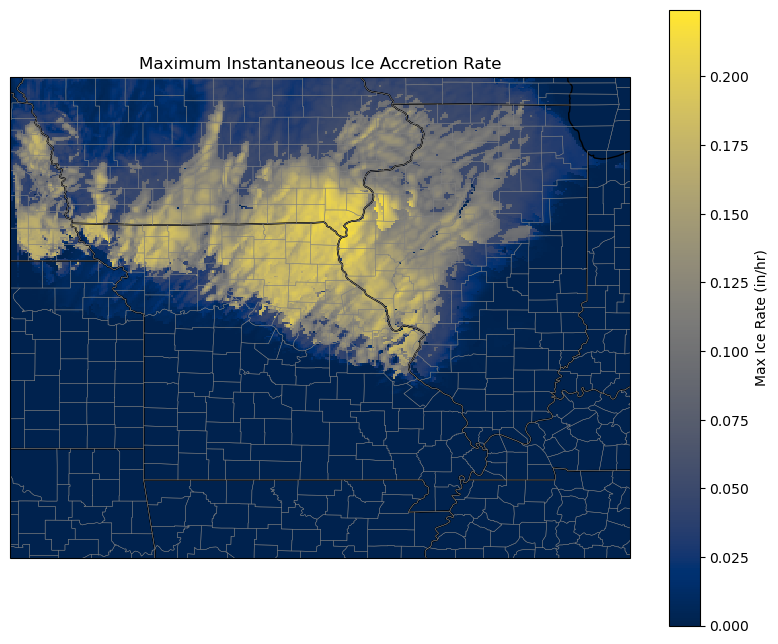

In [6]:
# Maximum Instantaneous Ice Accretion Rate (in/hr)
max_rate = processed_ds.ice_rate_in.max(dim="time")

plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = ax.pcolormesh(lons, lats, max_rate, transform=ccrs.PlateCarree(), cmap="cividis")
setup_map(ax)
ax.set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())
plt.colorbar(mesh, label="Max Ice Rate (in/hr)")
plt.title("Maximum Instantaneous Ice Accretion Rate")
plt.show()

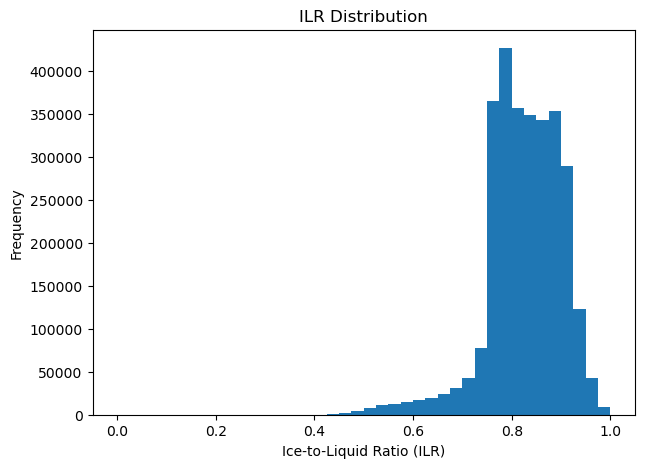

In [7]:
# ILR Distribution (only freezing fridpoints)
ilr_vals = processed_ds.ILR.where(processed_ds.wetbulb <= 0).values.flatten()
ilr_vals = ilr_vals[~np.isnan(ilr_vals)]

plt.figure(figsize=(7,5))
plt.hist(ilr_vals, bins=40)
plt.xlabel("Ice-to-Liquid Ratio (ILR)")
plt.ylabel("Frequency")
plt.title("ILR Distribution")
plt.show()

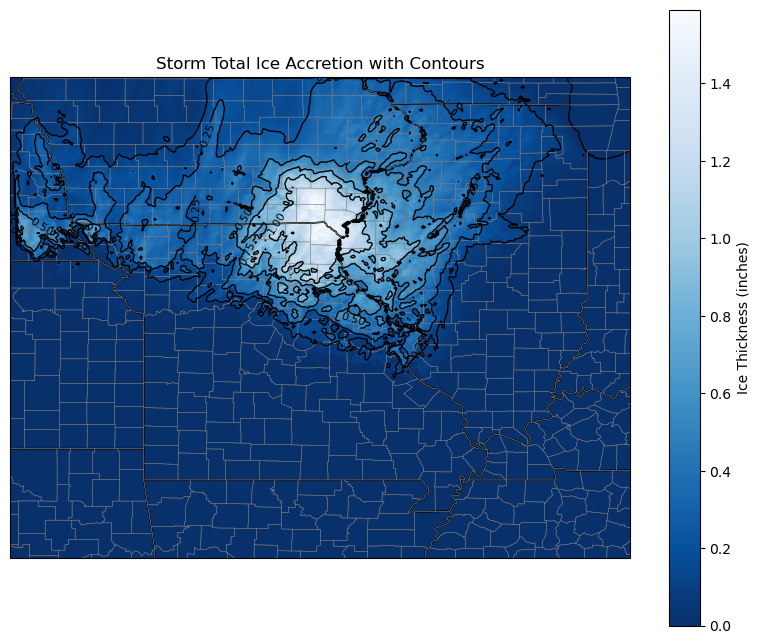

In [8]:
# Ice Thickness Contours (Final Time)
storm_total = processed_ds.ice_thickness_in.isel(time=-1)

plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
mesh = ax.pcolormesh(lons, lats, storm_total, transform=ccrs.PlateCarree(), cmap="Blues_r")
contours = ax.contour(lons, lats, storm_total, levels=[0.1, 0.25, 0.5, 0.75, 1.0], colors="black", linewidths=1, transform=ccrs.PlateCarree())
ax.clabel(contours, inline=True, fontsize=8)
setup_map(ax)
ax.set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())

plt.colorbar(mesh, label="Ice Thickness (inches)")
plt.title("Storm Total Ice Accretion with Contours")
plt.show()

/tmp/ipykernel_956005/3062749347.py:4: UserWarning: Adding colorbar to a different Figure <Figure size 1000x800 with 3 Axes> than <Figure size 1000x800 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(mesh, label="Ice Thickness (inches)")


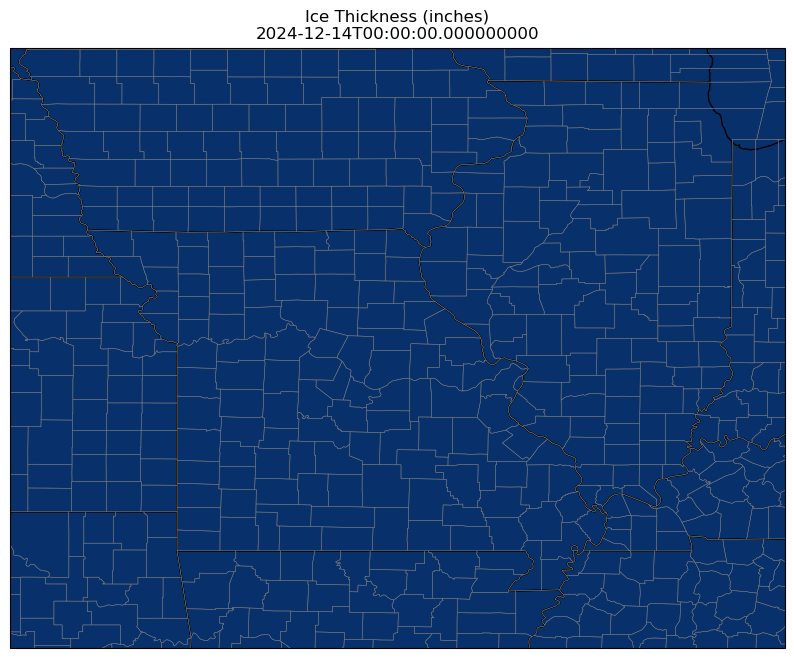

In [9]:
# ice thickness animation
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())
plt.colorbar(mesh, label="Ice Thickness (inches)")

def update(t):
    ax.clear()
    setup_map(ax)
    data = processed_ds.ice_thickness_in.isel(time=t)
    mesh = ax.pcolormesh(lons, lats, data, transform=ccrs.PlateCarree(), cmap="Blues_r")
    ax.set_extent([float(lons.min()), float(lons.max()), float(lats.min()), float(lats.max())], crs=ccrs.PlateCarree())
    ax.set_title(f"Ice Thickness (inches)\n{str(processed_ds.time.values[t])}")

ani = animation.FuncAnimation(fig, update, frames=len(processed_ds.time), interval=200)
ani.save("ice_thickness_animation.gif", writer="pillow", dpi=150)
ani.save("ice_thickness_animation.mp4", dpi=200, writer="ffmpeg")

In [10]:
reports = [
("Cedar Rapids Arpt", 0.68),
("2 SE Coralville", 0.50),
("3 NNE Cedar Rapids", 0.50),
("North Liberty", 0.50),
("Anamosa", 0.45),
("Marion", 0.42),
("Colchester", 0.40),
("Industry", 0.40),
("2 N Ely", 0.40),
("Parnell", 0.40),
("2 S Hiawatha", 0.40),
("2 N Central City", 0.40),
("1 ESE Solon", 0.38),
("1 NNE Oakdale", 0.38),
("Tiffin", 0.38),
("Manchester", 0.38),
("1 WNW Cou Falls", 0.37),
("2 ENE Hiawatha", 0.35),
("1 W Elmira", 0.35),
("1 SSW Washington", 0.32),
("Davenport Arpt", 0.32),
("Iowa City", 0.30),
("1 ENE Fairfax", 0.30),
("2 ESE Iowa City", 0.30),
("2 NE Cedar Rapids", 0.30),
("3 N Marion", 0.30),
("Stanwood", 0.30),
("Lowden", 0.30),
("Quad City Intl Arpt", 0.27),
("Dubuque Arpt", 0.26),
("1 NE Cedar Rapids", 0.25),
("Columbus City", 0.25),
("Carthage", 0.25),
("Cedar Rapids", 0.25),
("1 ENE North English", 0.25),
("2 E Cedar Rapids", 0.25),
("4 S Atkins", 0.25),
("1 SSW Mooar", 0.25),
("1 NE Spring Grove", 0.25),
("1 W Amana", 0.25),
("1 WNW Sigourney", 0.25),
("3 SW Yarmouth", 0.25),
("Riverside", 0.25),
("2 SW Sunbury", 0.25),
("Upper South Amana", 0.25),
("1 ENE Silvis", 0.25),
("1 SW Silvis", 0.25),
("2 NNE Iowa City", 0.25),
("Winfield", 0.25),
("Washington", 0.25),
("1 SSW Cordova", 0.24),
("3 ENE Charlie Heath Memorial", 0.20),
("2 SSE Burlington Regional Ai", 0.20),
("1 SW Perlee", 0.20),
("1 W Macomb", 0.20),
("3 W Mount Sterling", 0.20),
("1 ENE Burlington Regional Ai", 0.20),
("1 NE Iowa City", 0.20),
("1 W Industry", 0.20),
("2 S Coggon", 0.20),
("2 NNE New Windsor", 0.20),
("2 WNW Bettendorf", 0.20),
("2 ENE Hazleton", 0.20),
("1 SSW Coal Valley", 0.19),
("1 SSW Montrose", 0.16),
("Urbana", 0.15),
("1 SE Sand Hill", 0.13),
("2 NNE Muscatine", 0.13),
("1 NE Park View", 0.13),
("1 NNW Dewitt", 0.13),
("1 ENE Clinton", 0.13),
("Robins", 0.10),
("1 NW Center Grove", 0.10),
("Wyoming", 0.10),
("2 SSE Warner", 0.10),
("Bushnell", 0.10),
("Davis", 0.10),
("Rubio", 0.00),
("1 ENE Clinton (2)", 0.00),
("Cambridge", 0.00),
("Macomb", 0.00),
]